# 🌳 Decision Predicate Graph (DPG)
This notebook shows a minimal working example of using DPG on **iris** dataset.


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from dpg import DPGExplainer
from dpg.visualizer import plot_dpg


#### Training iris

In [3]:
# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Fit the model
model = RandomForestClassifier(n_estimators=3, random_state=42)
model.fit(X, y)


RandomForestClassifier(n_estimators=3, random_state=42)

#### Extracting DPG

In [4]:
explainer = DPGExplainer(
    model=model,
    feature_names=iris.feature_names,
    target_names=iris.target_names,
)

# Build global explanation with communities so downstream class-bound plots work
explanation = explainer.explain_global(X=X, communities=True, community_threshold=0.2)

# Backward-friendly aliases used by later cells
dot = explanation.dot
dpg_model = explanation.graph
nodes_list = explanation.nodes
df_nodes = explanation.node_metrics
df_edges = explanation.edge_metrics
df_metrics = explanation.class_boundaries

print('Class boundary classes:', list(df_metrics.get('Class Bounds', {}).keys()))


Config file not found at 'config.yaml'. Using built-in defaults.
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=-1

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  3
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 3, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
*****************************************************************


100%|██████████| 150/150 [00:01<00:00, 86.98it/s]


Total of paths: 450
Building DPG...


Processing cases: 100%|██████████| 450/450 [00:00<00:00, 31369.97it/s]

Extracting graph...
Class boundary classes: ['Class setosa', 'Class versicolor', 'Class virginica']


In [5]:
import pandas as pd

class_bounds = (explanation.class_boundaries or {}).get("Class Bounds", {})

df_bounds = (
    pd.DataFrame(
        [
            {
                "Class": str(class_name),
                "Constraints": ", ".join(sorted(map(str, bounds or []))),
            }
            for class_name, bounds in class_bounds.items()
        ]
    )
    .sort_values("Class", kind="stable")
    .reset_index(drop=True)
)

print(df_bounds)


              Class  \
0      Class setosa   
1  Class versicolor   
2   Class virginica   

                                                                                                            Constraints  
0                                                                     petal length (cm) <= 2.6, petal width (cm) <= 0.8  
1   0.8 < petal width (cm) <= 1.75, 2.6 < petal length (cm) <= 5.45, sepal length (cm) <= 6.15, sepal width (cm) > 2.25  
2  1.55 < petal width (cm) <= 1.75, 2.45 < petal length (cm) <= 4.85, sepal length (cm) > 5.95, sepal width (cm) <= 3.1  


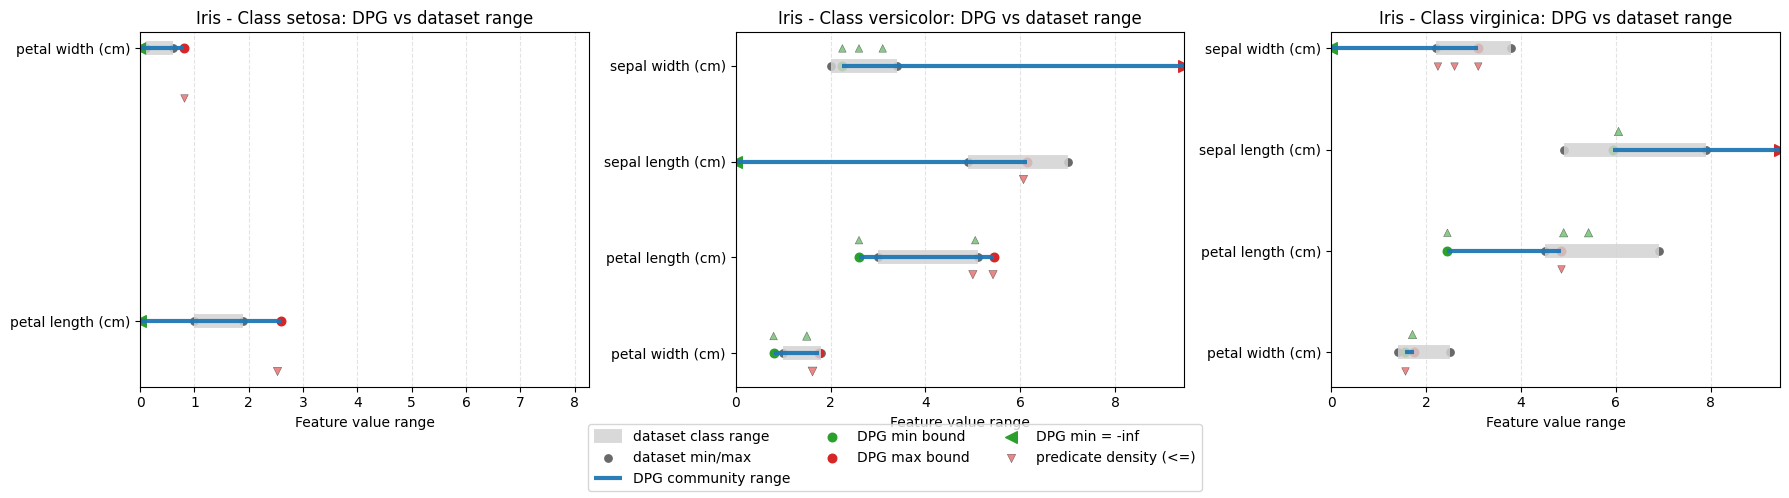

In [6]:
# Plot DPG class bounds vs dataset feature ranges
import numpy as np
import pandas as pd
from dpg.visualizer import (
    class_lookup_from_target_names,
    plot_dpg_class_bounds_vs_dataset_feature_ranges,
)

# Assumes these already exist in notebook:
# - explainer (DPGExplainer)
# - explanation (from explainer.explain_global(...))
# - X (features), y (labels)

# Ensure DataFrame/array shapes are compatible
X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=explainer.builder.feature_names)
y_arr = np.asarray(y)

# If explanation was built without communities, rebuild for community-derived bounds
if getattr(explanation, "communities", None) is None:
    explanation = explainer.explain_global(X_df.values, communities=True, community_threshold=0.2)

class_lookup = class_lookup_from_target_names(explainer.builder.target_names)

fig = plot_dpg_class_bounds_vs_dataset_feature_ranges(
    explanation=explanation,
    X_df=X_df,
    y=y_arr,
    dataset_name="Iris",
    top_features=4,
    class_lookup=class_lookup,
    save_path=None,   # set a path string if you want to save
    show=True,
)


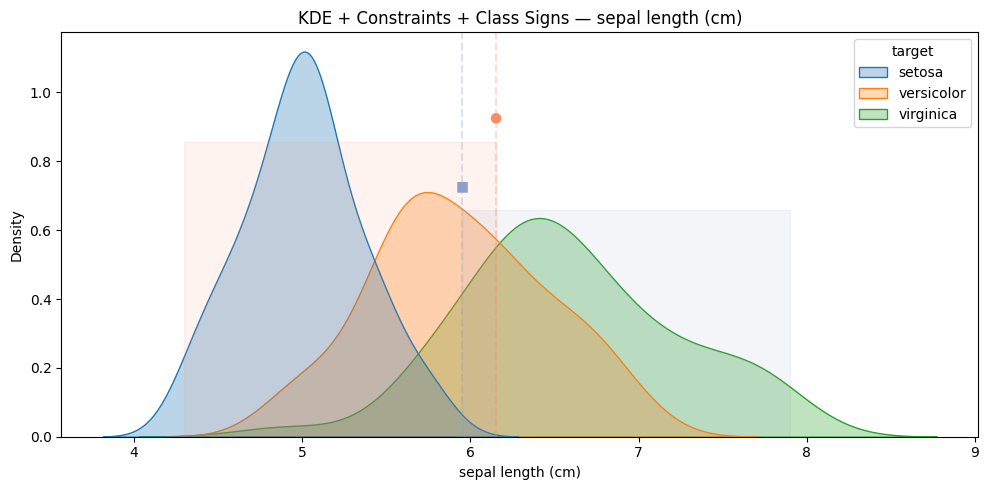

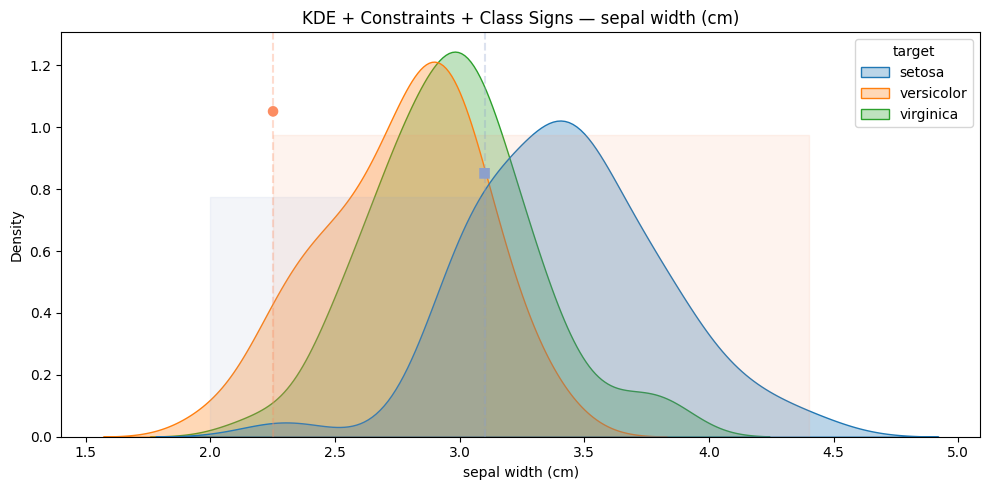

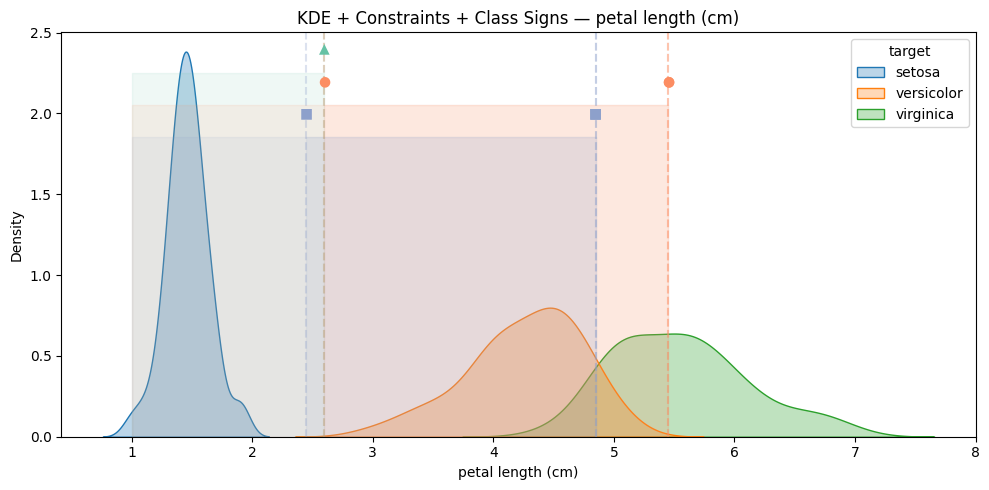

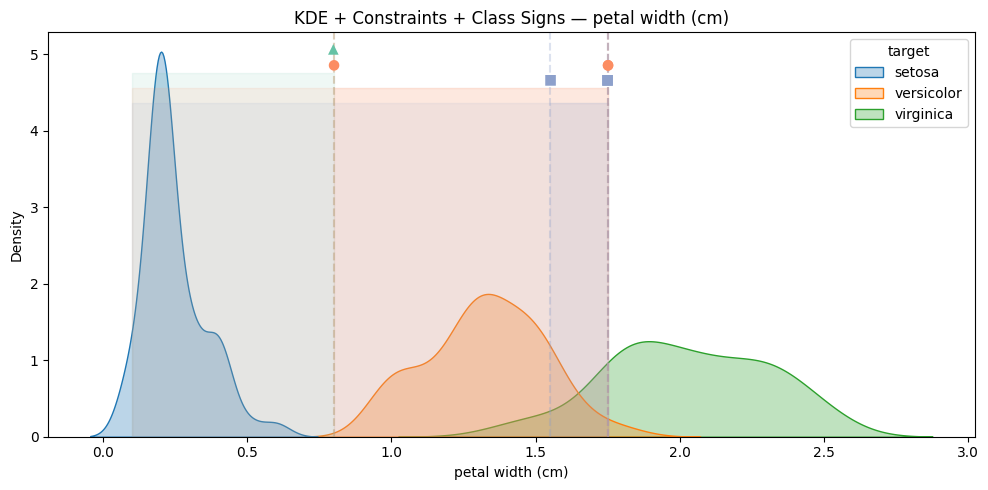

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
import re

# Load Iris dataset
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris["target"] = df_iris["target"].apply(lambda x: iris.target_names[x])

# Define signs per class
class_signs = {
    "setosa": "▲",
    "versicolor": "●",
    "virginica": "■"
}

# Extract actual features from the dataset
available_features = df_iris.columns[:-1].tolist()
palette = sns.color_palette("Set2", n_colors=len(df_bounds))

for feature in available_features:
    plt.figure(figsize=(10, 5))
    ax = sns.kdeplot(data=df_iris, x=feature, hue="target", fill=True, common_norm=False, alpha=0.3)
    plt.title(f"KDE + Constraints + Class Signs — {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")

    feature_min, feature_max = df_iris[feature].min(), df_iris[feature].max()

    for i, row in df_bounds.iterrows():
        class_label = row["Class"].replace("Class ", "")
        constraints = row["Constraints"]
        sign = class_signs.get(class_label, "")
        color = palette[i % len(palette)]

        # Handle bounded ranges: a < feature <= b
        matches_range = re.findall(rf"([\d\.-]+) < {re.escape(feature)} <= ([\d\.-]+)", constraints)
        for lower, upper in matches_range:
            lower, upper = float(lower), float(upper)
            plt.axvline(lower, color=color, linestyle="--", alpha=0.3)
            plt.axvline(upper, color=color, linestyle="--", alpha=0.3)
            plt.fill_betweenx([0, plt.ylim()[1]*0.9+(i*-0.2)], lower, upper, color=color, alpha=0.1)
            plt.text(lower, plt.ylim()[1]*0.95+(i*-0.2), sign, color=color, ha='center')
            plt.text(upper, plt.ylim()[1]*0.95+(i*-0.2), sign, color=color, ha='center')

        # Handle lower-bound only: feature > a
        matches_gt = re.findall(rf"{re.escape(feature)} > ([\d\.-]+)", constraints)
        for lower in matches_gt:
            lower = float(lower)
            plt.axvline(lower, color=color, linestyle="--", alpha=0.3)
            plt.fill_betweenx([0, plt.ylim()[1]*0.9+(i*-0.2)], lower, feature_max, color=color, alpha=0.1)
            plt.text(lower, plt.ylim()[1]*0.95+(i*-0.2), sign, color=color, ha='center')

        # Handle upper-bound only: feature <= b
        matches_le = re.findall(rf"{re.escape(feature)} <= ([\d\.-]+)", constraints)
        for upper in matches_le:
            upper = float(upper)
            plt.axvline(upper, color=color, linestyle="--", alpha=0.3)
            plt.fill_betweenx([0, plt.ylim()[1]*0.9+(i*-0.2)], feature_min, upper, color=color, alpha=0.1)
            plt.text(upper, plt.ylim()[1]*0.95+(i*-0.2), sign, color=color, ha='center')

    plt.tight_layout()
    plt.show()
